In [1]:
"""
!curl -L -o books.zip https://www.kaggle.com/api/v1/datasets/download/dylanjcastillo/7k-books-with-metadata
!unzip books.zip
""";

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('books.csv')
df.shape

(6810, 12)

In [4]:
df.head(3)

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6810 entries, 0 to 6809
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   isbn13          6810 non-null   int64  
 1   isbn10          6810 non-null   object 
 2   title           6810 non-null   object 
 3   subtitle        2381 non-null   object 
 4   authors         6738 non-null   object 
 5   categories      6711 non-null   object 
 6   thumbnail       6481 non-null   object 
 7   description     6548 non-null   object 
 8   published_year  6804 non-null   float64
 9   average_rating  6767 non-null   float64
 10  num_pages       6767 non-null   float64
 11  ratings_count   6767 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 638.6+ KB


In [6]:
df['missing_description'] = np.where(df['description'].isna(), 1, 0)

df['missing_description'].value_counts()

,count
missing_description,
0,6548
1,262


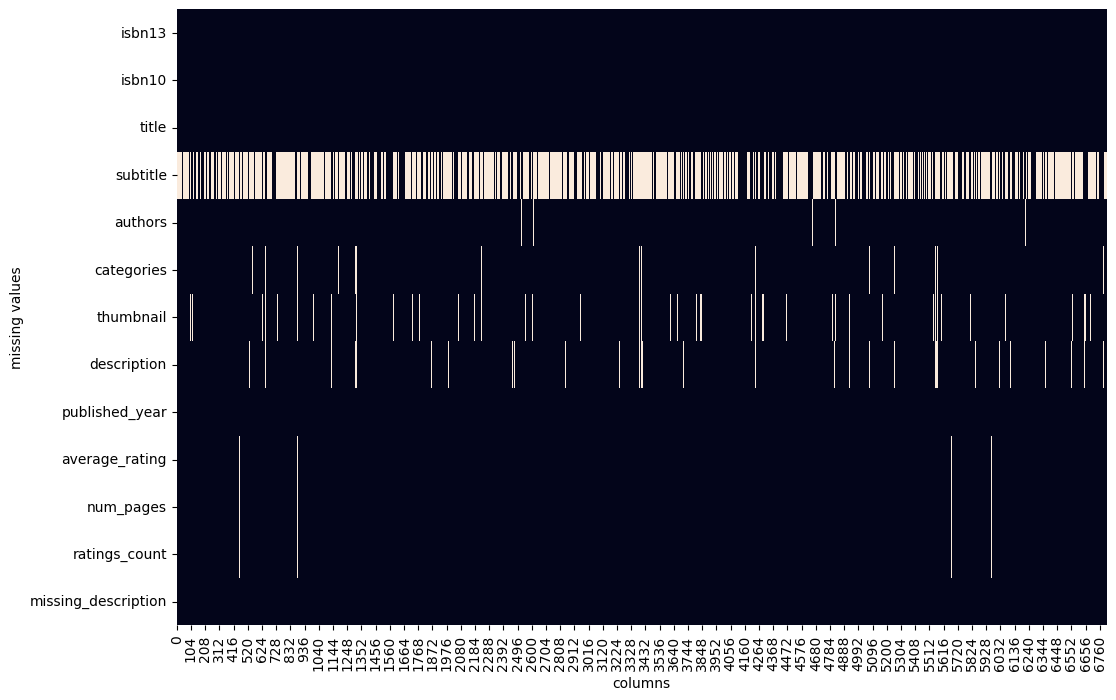

In [7]:
# adjust width, height in inches
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(df.isna().transpose(), cbar=False, ax=ax)

ax.set_xlabel('columns')
ax.set_ylabel('missing values')

plt.show()


In [8]:
# Age of the book relative to now
current_year = pd.Timestamp.now().year
df['age'] = current_year - df['published_year']

# Decade grouping
df['decade'] = (df['published_year'] // 10) * 10


In [9]:
df[['published_year', 'age', 'decade']].sample(n=10)

,published_year,age,decade
2387,1992.0,33.0,1990.0
310,2007.0,18.0,2000.0
2870,2006.0,19.0,2000.0
4036,1996.0,29.0,1990.0
222,1989.0,36.0,1980.0
2204,1998.0,27.0,1990.0
576,2003.0,22.0,2000.0
4916,2004.0,21.0,2000.0
6506,2003.0,22.0,2000.0
1965,2004.0,21.0,2000.0


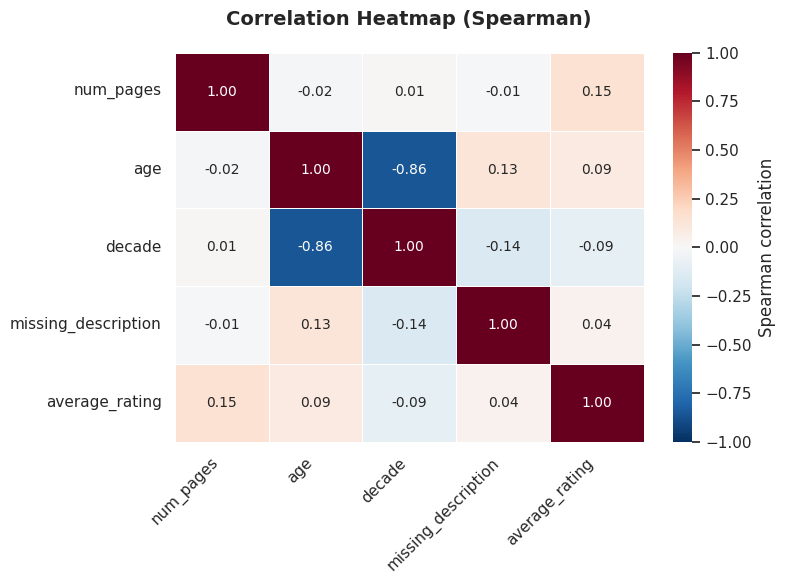

In [10]:
cols = [
    'num_pages',
    'age',
    'decade',
    'missing_description',
    'average_rating'
]

corr_matrix = df[cols].corr(method='spearman')

sns.set_theme(style="white")
plt.figure(figsize=(8, 6))

heatmap = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    cbar_kws={'label': 'Spearman correlation'},
    annot_kws={"size": 10},
    linewidths=0.5,
    linecolor='white',
    vmin=-1, vmax=1  # fix scale for consistency
)

heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, ha='right')
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0)

heatmap.set_title("Correlation Heatmap (Spearman)", fontsize=14, weight='bold', pad=20)

plt.tight_layout()
plt.show()


In [11]:
df['categories'].nunique()

567

In [12]:
df['categories'].value_counts().reset_index().head(10)

,categories,count
0,Fiction,2588
1,Juvenile Fiction,538
2,Biography & Autobiography,401
3,History,264
4,Literary Criticism,166
5,Philosophy,160
6,Comics & Graphic Novels,159
7,Religion,137
8,Drama,132
9,Juvenile Nonfiction,116
